# TF32: Precision vs Performance in Matrix Multiplication

**TensorFloat-32 (TF32)** is a math mode introduced with NVIDIA's Ampere architecture (SM80+). It is **not** a new storage format — tensors are still stored as FP32 (32-bit). Instead, TF32 is a **compute mode** used internally by Tensor Cores during matrix multiplication.

__Disclaimer__: The outputs of this notebook are from running it on a RTX-4070.

**Authors: Claude Code & Pramodith**

## How TF32 works

A standard FP32 number has:
- 1 sign bit, 8 exponent bits, 23 mantissa bits (total: 32 bits)

When TF32 mode is enabled, the Tensor Cores **truncate** each FP32 input to:
- 1 sign bit, 8 exponent bits, **10 mantissa bits** (same mantissa width as FP16)

The key insight: TF32 keeps the **full FP32 range** (8-bit exponent) but reduces **precision** (10-bit mantissa). The accumulation is still done in full FP32, so only the inputs to each fused multiply-add are truncated.

```
FP32:  [1 sign] [8 exponent] [23 mantissa] = 32 bits  (stored & computed)
TF32:  [1 sign] [8 exponent] [10 mantissa] = 19 bits  (computed only, not stored)
FP16:  [1 sign] [5 exponent] [10 mantissa] = 16 bits
BF16:  [1 sign] [8 exponent] [7 mantissa]  = 16 bits
```

## Why TF32 exists

Tensor Cores on Ampere+ GPUs can execute TF32 matrix multiplications **much faster** than full FP32 — roughly 8x more FLOPS on A100. Since many deep learning workloads don't need all 23 bits of mantissa precision, TF32 gives a near-free speedup for training and inference.

## PyTorch control flags

As of PyTorch 2.9+, TF32 usage is controlled via precision strings (the older boolean `allow_tf32` flags are deprecated):

- `torch.backends.cuda.matmul.fp32_precision` — controls whether `torch.matmul` (and `@`) can use TF32 Tensor Cores.
  - `"ieee"` — strict FP32, no TF32 (**default** for matmul).
  - `"tf32"` — enables TF32 Tensor Cores (inputs truncated to 10-bit mantissa, accumulation in FP32).
- `torch.backends.cudnn.conv.fp32_precision` — controls whether cuDNN convolutions can use TF32.
  - `"tf32"` — TF32 enabled (**default** for convolutions).
  - `"ieee"` — strict FP32.

## What this notebook demonstrates

1. **Precision impact**: We compare FP32 matmul results (with TF32 on vs off) against an FP64 reference to quantify the precision loss from mantissa truncation.
2. **Performance impact**: We benchmark matmul across multiple matrix sizes to show the speedup TF32 provides.

In [1]:
%pip install -q torch triton

In [2]:
import torch
import triton
import matplotlib.pyplot as plt
import numpy as np

assert torch.cuda.is_available(), "CUDA GPU required"
major, _ = torch.cuda.get_device_capability()
assert major >= 8, f"TF32 requires Ampere (SM80+), got SM{major}0"

print(f"GPU: {torch.cuda.get_device_name()}")
print(f"Compute capability: {torch.cuda.get_device_capability()}")
print(f"PyTorch version: {torch.__version__}")

GPU: NVIDIA GeForce RTX 4070
Compute capability: (8, 9)
PyTorch version: 2.10.0+cu128


## Part 1: Precision Comparison

We compute `C = A @ B` three ways:
1. **FP64 reference** — double-precision matmul (highest accuracy, our ground truth)
2. **FP32 with TF32 disabled** — full single-precision on Tensor Cores
3. **FP32 with TF32 enabled** — Tensor Cores truncate inputs to 10-bit mantissa

We then measure the error of both FP32 variants against the FP64 reference.

In [13]:
def measure_precision(M, K, N, seed=None, return_errors=False):
    """Compare matmul precision: TF32-enabled FP32 vs TF32-disabled FP32 vs FP64 reference."""
    if seed is not None:
        torch.manual_seed(seed)

    # Generate random matrices in FP32
    A_fp32 = torch.randn(M, K, device="cuda", dtype=torch.float32)
    B_fp32 = torch.randn(K, N, device="cuda", dtype=torch.float32)

    # FP64 reference (ground truth)
    A_fp64 = A_fp32.double()
    B_fp64 = B_fp32.double()
    C_ref = A_fp64 @ B_fp64

    # FP32 with TF32 disabled (strict IEEE FP32)
    torch.backends.cuda.matmul.fp32_precision = "ieee"
    C_fp32 = A_fp32 @ B_fp32

    # FP32 with TF32 enabled (truncated mantissa)
    torch.backends.cuda.matmul.fp32_precision = "tf32"
    C_tf32 = A_fp32 @ B_fp32

    # Compute errors in FP64 to avoid contamination from casting the reference down
    fp32_abs_err = (C_fp32.double() - C_ref).abs()
    tf32_abs_err = (C_tf32.double() - C_ref).abs()

    # Relative error (avoid division by zero)
    C_ref_abs = C_ref.abs().clamp(min=1e-8)
    fp32_rel_err = fp32_abs_err / C_ref_abs
    tf32_rel_err = tf32_abs_err / C_ref_abs

    stats = {
        "fp32_max_abs": fp32_abs_err.max().item(),
        "tf32_max_abs": tf32_abs_err.max().item(),
        "fp32_mean_abs": fp32_abs_err.mean().item(),
        "tf32_mean_abs": tf32_abs_err.mean().item(),
        "fp32_max_rel": fp32_rel_err.max().item(),
        "tf32_max_rel": tf32_rel_err.max().item(),
        "fp32_mean_rel": fp32_rel_err.mean().item(),
        "tf32_mean_rel": tf32_rel_err.mean().item(),
    }

    if return_errors:
        return stats, fp32_abs_err.float(), tf32_abs_err.float()
    return stats

In [14]:
sizes = [256, 512, 1024, 2048, 4096]

print(f"{'Size':>10} | {'FP32 Mean Abs Err':>18} | {'TF32 Mean Abs Err':>18} | {'FP32 Mean Rel Err':>18} | {'TF32 Mean Rel Err':>18}")
print("-" * 95)

all_results = []
for i, N in enumerate(sizes):
    res = measure_precision(N, N, N, seed=42 + i)
    all_results.append(res)
    print(f"{N:>10} | {res['fp32_mean_abs']:>18.6e} | {res['tf32_mean_abs']:>18.6e} | {res['fp32_mean_rel']:>18.6e} | {res['tf32_mean_rel']:>18.6e}")

      Size |  FP32 Mean Abs Err |  TF32 Mean Abs Err |  FP32 Mean Rel Err |  TF32 Mean Rel Err
-----------------------------------------------------------------------------------------------
       256 |       1.834181e-06 |       3.731635e-03 |       9.856860e-07 |       2.431737e-03
       512 |       4.833272e-06 |       5.294188e-03 |       1.733667e-06 |       2.038710e-03
      1024 |       6.440726e-06 |       7.473197e-03 |       2.404995e-06 |       2.892038e-03
      2048 |       1.609721e-05 |       1.060181e-02 |       6.183761e-06 |       3.243040e-03
      4096 |       3.849360e-05 |       1.501010e-02 |       7.072392e-06 |       3.209101e-03


### Visualizing the Precision Gap

The bar chart below shows mean relative error for FP32 (TF32 off) vs FP32 (TF32 on) at each matrix size. The error grows with matrix size because larger reductions accumulate more rounding errors from the truncated mantissa.

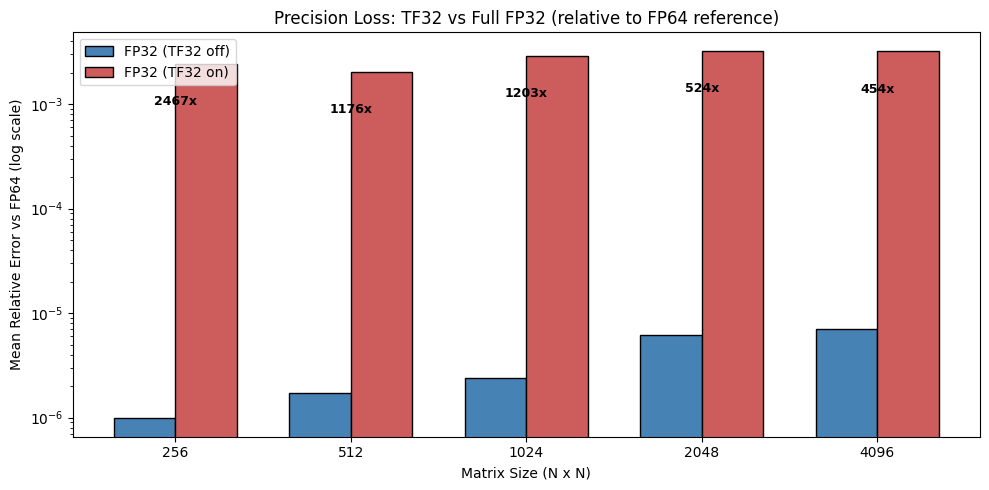

In [15]:
x = np.arange(len(sizes))
width = 0.35

fp32_rel = [r["fp32_mean_rel"] for r in all_results]
tf32_rel = [r["tf32_mean_rel"] for r in all_results]

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width / 2, fp32_rel, width, label="FP32 (TF32 off)", color="steelblue", edgecolor="black")
bars2 = ax.bar(x + width / 2, tf32_rel, width, label="FP32 (TF32 on)", color="indianred", edgecolor="black")

ax.set_yscale("log")

# Annotate ratio between the two bars, placed inside the taller bar
for i in range(len(sizes)):
    ratio = tf32_rel[i] / fp32_rel[i] if fp32_rel[i] > 0 else 0
    top = max(fp32_rel[i], tf32_rel[i])
    ax.text(x[i], top * 0.5, f"{ratio:.0f}x", ha="center", va="top", fontsize=9, fontweight="bold")

ax.set_xlabel("Matrix Size (N x N)")
ax.set_ylabel("Mean Relative Error vs FP64 (log scale)")
ax.set_title("Precision Loss: TF32 vs Full FP32 (relative to FP64 reference)")
ax.set_xticks(x)
ax.set_xticklabels([str(s) for s in sizes])
ax.legend()

plt.tight_layout()
plt.show()

## Part 2: Performance Benchmarking

Now we benchmark `torch.matmul` with TF32 enabled vs disabled across a range of matrix sizes using `triton.testing.do_bench`. On Ampere+ GPUs, TF32 should be significantly faster because Tensor Cores process the reduced-precision inputs at higher throughput.

In [16]:
bench_sizes = [256, 512, 1024, 2048, 4096, 8192]

bench_results = []

print(f"{'Size':>8} | {'FP32 (TF32 off) ms':>19} | {'FP32 (TF32 on) ms':>18} | {'Speedup':>8}")
print("-" * 62)

for N in bench_sizes:
    A = torch.randn(N, N, device="cuda", dtype=torch.float32)
    B = torch.randn(N, N, device="cuda", dtype=torch.float32)

    # Benchmark with TF32 disabled (strict IEEE FP32)
    torch.backends.cuda.matmul.fp32_precision = "ieee"
    ms_fp32 = triton.testing.do_bench(lambda: A @ B, warmup=25, rep=100)

    # Benchmark with TF32 enabled
    torch.backends.cuda.matmul.fp32_precision = "tf32"
    ms_tf32 = triton.testing.do_bench(lambda: A @ B, warmup=25, rep=100)

    speedup = ms_fp32 / ms_tf32
    bench_results.append((N, ms_fp32, ms_tf32, speedup))
    print(f"{N:>8} | {ms_fp32:>19.4f} | {ms_tf32:>18.4f} | {speedup:>7.2f}x")

    Size |  FP32 (TF32 off) ms |  FP32 (TF32 on) ms |  Speedup
--------------------------------------------------------------
     256 |              0.0143 |             0.0104 |    1.37x


     512 |              0.0370 |             0.0188 |    1.97x
    1024 |              0.1393 |             0.0924 |    1.51x
    2048 |              0.9506 |             0.5934 |    1.60x
    4096 |              6.3337 |             4.4386 |    1.43x
    8192 |             53.0944 |            34.7151 |    1.53x


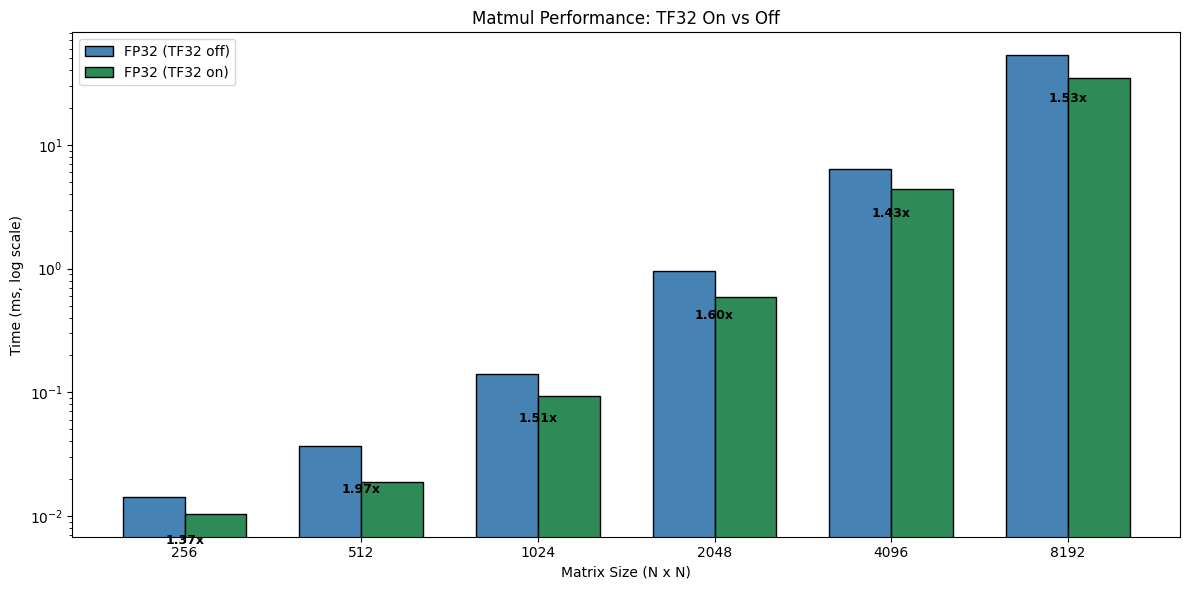

In [17]:
labels = [str(s) for s in bench_sizes]
fp32_times = [r[1] for r in bench_results]
tf32_times = [r[2] for r in bench_results]
speedups = [r[3] for r in bench_results]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width / 2, fp32_times, width, label="FP32 (TF32 off)", color="steelblue", edgecolor="black")
bars2 = ax.bar(x + width / 2, tf32_times, width, label="FP32 (TF32 on)", color="seagreen", edgecolor="black")

ax.set_yscale("log")

# Annotate speedup inside the taller bar
for i, (b1, b2, s) in enumerate(zip(bars1, bars2, speedups)):
    top = max(b1.get_height(), b2.get_height())
    ax.text(x[i], top * 0.5, f"{s:.2f}x", ha="center", va="top", fontsize=9, fontweight="bold")

ax.set_xlabel("Matrix Size (N x N)")
ax.set_ylabel("Time (ms, log scale)")
ax.set_title("Matmul Performance: TF32 On vs Off")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.tight_layout()
plt.show()

## TFLOPS Comparison

To better understand the throughput difference, let's compute TFLOPS (tera floating-point operations per second) for each configuration. A matmul of two NxN matrices requires `2 * N^3` FLOPs.

In [9]:
print(f"{'Size':>8} | {'FP32 TFLOPS':>12} | {'TF32 TFLOPS':>12} | {'Speedup':>8}")
print("-" * 50)

for N, ms_fp32, ms_tf32, speedup in bench_results:
    flops = 2 * N**3
    tflops_fp32 = flops / (ms_fp32 * 1e-3) / 1e12
    tflops_tf32 = flops / (ms_tf32 * 1e-3) / 1e12
    print(f"{N:>8} | {tflops_fp32:>12.2f} | {tflops_tf32:>12.2f} | {speedup:>7.2f}x")

    Size |  FP32 TFLOPS |  TF32 TFLOPS |  Speedup
--------------------------------------------------
     256 |         2.40 |         3.25 |    1.35x
     512 |         7.46 |        14.40 |    1.93x
    1024 |        15.43 |        23.19 |    1.50x
    2048 |        18.20 |        28.95 |    1.59x
    4096 |        22.07 |        30.43 |    1.38x
    8192 |        20.30 |        31.85 |    1.57x
